In [1]:
print("Predictive Maintenance Project Started")

Predictive Maintenance Project Started


In [2]:
import pandas as pd
import numpy as np

In [6]:
data = pd.read_csv("../data/maintenance_data.csv")

In [8]:
data.head()

,equipment_id,equipment_type,runtime_hours,temperature,fault_count_30_days,downtime_minutes_30_days,days_since_last_pm,sensor_reading,throughput_rate,failure_next_7_days,fault_type
0,EQ_0001,conveyor,910,84.52,2,87,117,40.77,1623,0,none
1,EQ_0002,conveyor,2969,71.03,2,235,89,42.12,2084,1,motor_fault
2,EQ_0003,sorter,524,65.85,2,174,62,54.71,1062,0,none
3,EQ_0004,sorter,1949,108.71,0,306,7,55.91,520,1,sensor_fault
4,EQ_0005,conveyor,2938,70.79,2,263,47,45.62,534,0,none


In [10]:
data.shape

(500, 11)

In [12]:
data.columns

Index(['equipment_id', 'equipment_type', 'runtime_hours', 'temperature',
       'fault_count_30_days', 'downtime_minutes_30_days', 'days_since_last_pm',
       'sensor_reading', 'throughput_rate', 'failure_next_7_days',
       'fault_type'],
      dtype='str')

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   equipment_id              500 non-null    str    
 1   equipment_type            500 non-null    str    
 2   runtime_hours             500 non-null    int64  
 3   temperature               500 non-null    float64
 4   fault_count_30_days       500 non-null    int64  
 5   downtime_minutes_30_days  500 non-null    int64  
 6   days_since_last_pm        500 non-null    int64  
 7   sensor_reading            500 non-null    float64
 8   throughput_rate           500 non-null    int64  
 9   failure_next_7_days       500 non-null    int64  
 10  fault_type                500 non-null    str    
dtypes: float64(2), int64(6), str(3)
memory usage: 53.0 KB


In [15]:
data.describe()

,runtime_hours,temperature,fault_count_30_days,downtime_minutes_30_days,days_since_last_pm,sensor_reading,throughput_rate,failure_next_7_days
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1549.838000,77.569020,2.962000,197.040000,60.128000,49.830740,1458.996000,0.266000
std,870.261555,12.436794,1.777322,110.817252,34.102868,15.443889,569.735779,0.442307
min,55.000000,36.260000,0.000000,2.000000,1.000000,1.410000,507.000000,0.000000
25%,733.500000,69.480000,2.000000,104.750000,32.000000,39.582500,976.000000,0.000000
50%,1584.500000,77.040000,3.000000,195.000000,61.000000,50.320000,1414.000000,0.000000
75%,2329.250000,84.737500,4.000000,286.000000,89.000000,60.625000,1960.250000,1.000000
max,2981.000000,116.240000,9.000000,399.000000,119.000000,97.900000,2498.000000,1.000000


In [16]:
data.isnull().sum()

equipment_id                0
equipment_type              0
runtime_hours               0
temperature                 0
fault_count_30_days         0
downtime_minutes_30_days    0
days_since_last_pm          0
sensor_reading              0
throughput_rate             0
failure_next_7_days         0
fault_type                  0
dtype: int64

In [17]:
data["failure_next_7_days"].value_counts()

failure_next_7_days
0    367
1    133
Name: count, dtype: int64

In [19]:
data["fault_type"].value_counts()

fault_type
none            367
sensor_fault     35
overheating      31
jam              27
belt_issues      22
motor_fault      18
Name: count, dtype: int64

In [21]:
data.groupby("failure_next_7_days")[[
    "runtime_hours",
    "temperature",
    "fault_count_30_days",
    "downtime_minutes_30_days",
    "days_since_last_pm",
    "sensor_reading",
    "throughput_rate",
]].mean()

,runtime_hours,temperature,fault_count_30_days,downtime_minutes_30_days,days_since_last_pm,sensor_reading,throughput_rate
failure_next_7_days,,,,,,,
0,1337.493188,76.139319,2.825613,184.782016,51.673025,50.481390,1463.029973
1,2135.781955,81.514135,3.338346,230.864662,83.458647,48.035338,1447.864662


<Axes: title={'center': 'Failure Prediction Count'}, xlabel='failure_next_7_days'>

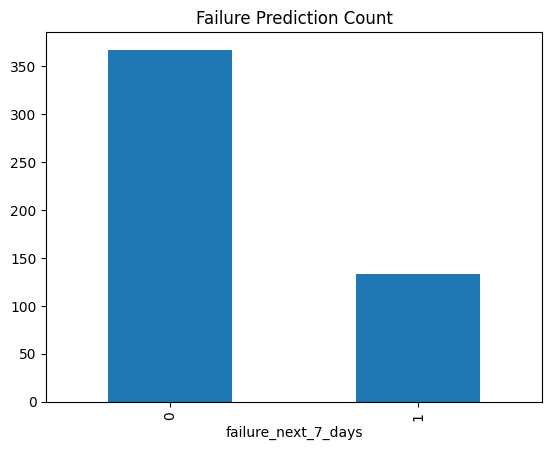

In [22]:
data["failure_next_7_days"].value_counts().plot(kind="bar", title="Failure Prediction Count")

<Axes: title={'center': 'temperature'}, xlabel='failure_next_7_days'>

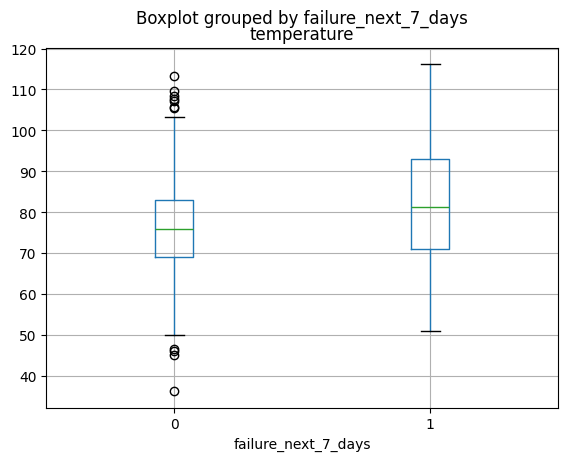

In [24]:
data.boxplot(column="temperature", by="failure_next_7_days")